In [1]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import h5py
from pathlib import Path
from scipy import sparse
import anndata
import seaborn as sns

c:\MA2\Hackaton\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
current_path = Path.cwd()

file_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "filtered_feature_bc_matrix.h5"
differential_expression_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "diffexp" / "gene_expression_graphclust" / "differential_expression.csv"
clusters_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "clustering" / "gene_expression_graphclust" / "clusters.csv"
tissue_positions_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "spatial" / "tissue_positions.parquet"


with h5py.File(file_path, "r") as f:
    print(list(f.keys()))  # shows top-level groups/datasets

with h5py.File(file_path, "r") as f:
    print(list(f["matrix"].keys()))

['matrix']
['barcodes', 'data', 'features', 'indices', 'indptr', 'shape']


In [3]:
with h5py.File(file_path, "r") as f:
    data = f["matrix/data"][:]
    indices = f["matrix/indices"][:]
    indptr = f["matrix/indptr"][:]
    shape = f["matrix/shape"][:]

# Build sparse count matrix
matrix = sparse.csc_matrix((data, indices, indptr), shape=shape)
print(matrix.shape)

(38606, 167450)


In [4]:
adata = anndata.AnnData(X=matrix.T)  # usually transpose: cells × genes

In [5]:
# Load CSVs
diffexp_df = pd.read_csv(differential_expression_path)
clusters_df = pd.read_csv(clusters_path)

# Preview
diffexp_df

,Feature ID,Feature Name,Cluster 1 Mean Counts,Cluster 1 Log2 fold change,Cluster 1 Adjusted p value,Cluster 2 Mean Counts,Cluster 2 Log2 fold change,Cluster 2 Adjusted p value,Cluster 3 Mean Counts,Cluster 3 Log2 fold change,Cluster 3 Adjusted p value,Cluster 4 Mean Counts,Cluster 4 Log2 fold change,Cluster 4 Adjusted p value,Cluster 5 Mean Counts,Cluster 5 Log2 fold change,Cluster 5 Adjusted p value
0,ENSG00000238009,ENSG00000238009,0.000042,2.171718,2.305574e-01,0.000000,-1.211420,5.090305e-01,0.000000,2.440397,1.000000,0.000000,0.879356,1.000000,0.000000,3.031347,1.0
1,ENSG00000291215,ENSG00000291215,0.000727,1.912074,1.077689e-06,0.000121,-2.211420,1.110393e-05,0.000000,-1.680619,0.805163,0.000501,0.237810,1.000000,0.000000,-1.089669,1.0
2,ENSG00000237491,LINC01409,0.000083,0.019715,1.000000e+00,0.000121,0.940583,4.765922e-01,0.000000,0.762325,1.000000,0.000000,-0.798716,0.768209,0.000000,1.353275,1.0
3,ENSG00000290784,ENSG00000290784,0.000010,-0.735173,7.495938e-01,0.000017,0.525546,1.000000e+00,0.000000,2.762325,1.000000,0.000056,2.616322,0.593622,0.000000,3.353275,1.0
4,ENSG00000177757,FAM87B,0.000000,-1.150210,6.267450e-01,0.000000,0.110508,1.000000e+00,0.000154,5.762325,0.605730,0.000000,2.201284,1.000000,0.000000,4.353275,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22771,ENSG00000273748,ENSG00000273748,0.000042,-0.828282,5.466988e-01,0.000086,0.888116,5.409140e-01,0.000000,1.177362,1.000000,0.000056,0.741853,1.000000,0.000229,2.893843,1.0
22772,ENSG00000271254,ENSG00000271254,0.000073,1.264827,3.199077e-01,0.000017,-1.059417,5.043690e-01,0.000000,1.440397,1.000000,0.000056,1.031359,0.996609,0.000000,2.031347,1.0
22773,ENSG00000276345,ENSG00000276345,0.000031,0.264827,1.000000e+00,0.000035,0.695471,8.475932e-01,0.000000,2.177362,1.000000,0.000000,0.616322,1.000000,0.000000,2.768312,1.0
22774,ENSG00000273554,ENSG00000273554,0.000706,3.636386,1.148400e-12,0.000035,-3.454276,6.193221e-08,0.000307,0.197540,1.000000,0.000000,-2.988540,0.014041,0.000000,-0.836550,1.0


In [6]:
positions_df = pd.read_parquet(tissue_positions_path, engine='fastparquet')
positions_df

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
0,s_008um_00000_00000-1,0,0,0,19858.364069,23765.912365
1,s_008um_00000_00001-1,0,0,1,19826.304160,23766.766875
2,s_008um_00000_00002-1,0,0,2,19794.244252,23767.621384
3,s_008um_00000_00003-1,0,0,3,19762.184345,23768.475893
4,s_008um_00000_00004-1,0,0,4,19730.124439,23769.330402
...,...,...,...,...,...,...
702239,s_008um_00837_00833-1,0,837,833,-7562.274481,-2357.447094
702240,s_008um_00837_00834-1,0,837,834,-7594.334537,-2356.592158
702241,s_008um_00837_00835-1,0,837,835,-7626.394593,-2355.737221
702242,s_008um_00837_00836-1,0,837,836,-7658.454647,-2354.882285


In [7]:
# Ensure matching column names
clusters_df = clusters_df.rename(columns={"Barcode": "barcode"})

# save clusters_df to a new CSV file
clusters_df.to_csv(current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "clustering" / "gene_expression_graphclust" / "clusters_renamed.csv", index=False)

# Merge spatial coords + cluster labels
plot_df = positions_df.merge(clusters_df, on="barcode", how="inner")

# (Optional) keep only spots in tissue
plot_df = plot_df[plot_df["in_tissue"] == 1]

In [8]:
clusters_df.head()

,barcode,Cluster
0,s_008um_00357_00397-1,2
1,s_008um_00260_00253-1,2
2,s_008um_00466_00453-1,1
3,s_008um_00474_00251-1,2
4,s_008um_00266_00304-1,2


In [9]:
# For each cluster, count how many spots belong to it, then compute the percentage of total spots for each cluster
cluster_counts = plot_df["Cluster"].value_counts()
cluster_percentages = cluster_counts / cluster_counts.sum() * 100

In [10]:
# Custom color palette 

n_clusters = plot_df["Cluster"].nunique()
cluster_ids = sorted(plot_df["Cluster"].unique())

custom_palette = {
    cluster_ids[0]: "#F25858",   # blue of the tumor
    cluster_ids[1]: "#AD1E13",   # red
    cluster_ids[2]: "#9C27B0",   # purple
    cluster_ids[3]: "#4CAF50",   # green
    cluster_ids[4]: "#FF9800",   # orange
}

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


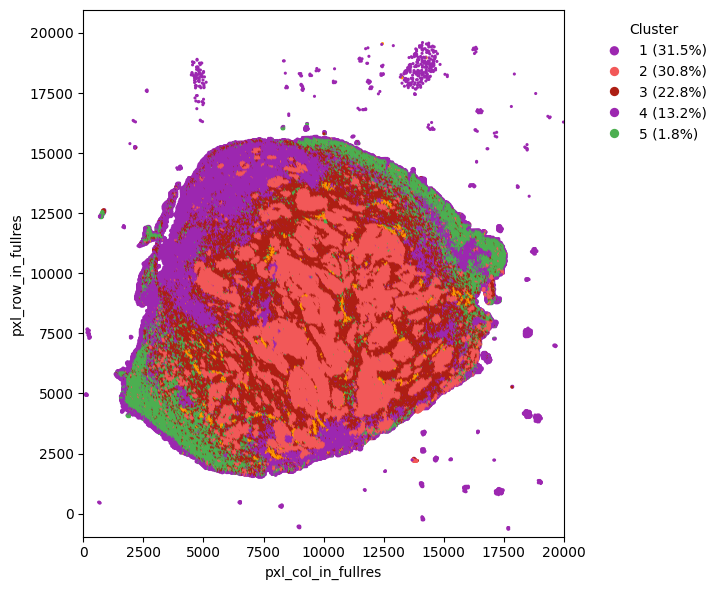

In [11]:
from matplotlib.pyplot import savefig


plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=plot_df,
    x="pxl_col_in_fullres",
    y="pxl_row_in_fullres",
    hue="Cluster",
    palette=custom_palette,
    s=5,
    linewidth=0
)
plt.gca().invert_yaxis()  # image-style orientation
plt.axis("equal")
plt.tight_layout()
plt.xlim(0, 20000)
plt.ylim(0, 20000)
plt.legend(
    title="Cluster",
    markerscale=3,               # bigger dots in legend
    bbox_to_anchor=(1.05, 1),    # place legend outside the plot
    loc="upper left",
    frameon=False,
    labels=[
    f"{cluster} ({cluster_percentages[cluster]:.1f}%)"
    for cluster in sorted(cluster_percentages.index)
]     
)
plt.show()


### UMAP

In [12]:
# rename column barcode as Barcode
clusters_df = clusters_df.rename(columns={"barcode": "Barcode"})
clusters_df.head(5)

,Barcode,Cluster
0,s_008um_00357_00397-1,2
1,s_008um_00260_00253-1,2
2,s_008um_00466_00453-1,1
3,s_008um_00474_00251-1,2
4,s_008um_00266_00304-1,2


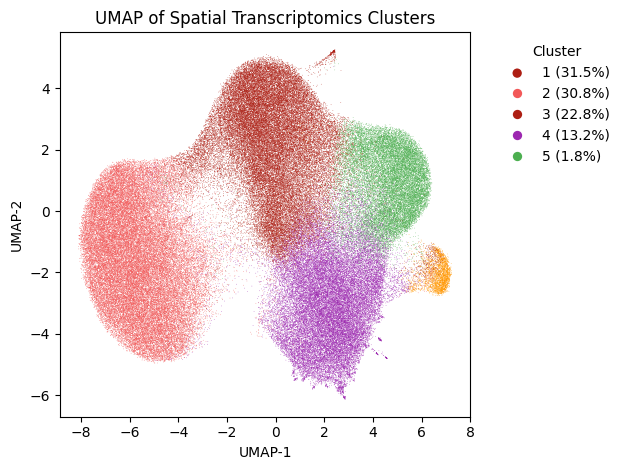

In [13]:
# load path to UMAP : C:\MA2\Hackaton\Ovarian-Cancer-Tumor-Microenvironment\A1\outs\binned_outputs\square_008um\analysis\umap\gene_expression_2_components

umap_path = current_path / "A1" / "outs" / "binned_outputs" / "square_008um" / "analysis" / "umap" / "gene_expression_2_components" / "projection.csv"

umap_df = pd.read_csv(umap_path, index_col=0)
umap_df.head()

# Plot UMAP : x = UMAP1, y = UMAP2, color by Cluster
umap_df = umap_df.merge(clusters_df, on="Barcode", how="inner")
sns.scatterplot(
    data=umap_df,
    x="UMAP-1",
    y="UMAP-2",
    hue="Cluster",
    palette=custom_palette,
    s=0.2,
    linewidth=0
)
plt.legend(
    title="Cluster",
    markerscale=15,               # bigger dots in legend
    bbox_to_anchor=(1.05, 1),    # place legend outside the plot
    loc="upper left",
    frameon=False,
    labels=[
    f"{cluster} ({cluster_percentages[cluster]:.1f}%)"
    for cluster in sorted(cluster_percentages.index)
    ]
)
plt.title("UMAP of Spatial Transcriptomics Clusters")
plt.tight_layout()
plt.show()

## Let's get for each gene the one with differential gene expression with p-value < 0.05

In [14]:
diffexp_df.head()

,Feature ID,Feature Name,Cluster 1 Mean Counts,Cluster 1 Log2 fold change,Cluster 1 Adjusted p value,Cluster 2 Mean Counts,Cluster 2 Log2 fold change,Cluster 2 Adjusted p value,Cluster 3 Mean Counts,Cluster 3 Log2 fold change,Cluster 3 Adjusted p value,Cluster 4 Mean Counts,Cluster 4 Log2 fold change,Cluster 4 Adjusted p value,Cluster 5 Mean Counts,Cluster 5 Log2 fold change,Cluster 5 Adjusted p value
0,ENSG00000238009,ENSG00000238009,0.000042,2.171718,0.230557,0.000000,-1.211420,0.509031,0.000000,2.440397,1.000000,0.000000,0.879356,1.000000,0.0,3.031347,1.0
1,ENSG00000291215,ENSG00000291215,0.000727,1.912074,0.000001,0.000121,-2.211420,0.000011,0.000000,-1.680619,0.805163,0.000501,0.237810,1.000000,0.0,-1.089669,1.0
2,ENSG00000237491,LINC01409,0.000083,0.019715,1.000000,0.000121,0.940583,0.476592,0.000000,0.762325,1.000000,0.000000,-0.798716,0.768209,0.0,1.353275,1.0
3,ENSG00000290784,ENSG00000290784,0.000010,-0.735173,0.749594,0.000017,0.525546,1.000000,0.000000,2.762325,1.000000,0.000056,2.616322,0.593622,0.0,3.353275,1.0
4,ENSG00000177757,FAM87B,0.000000,-1.150210,0.626745,0.000000,0.110508,1.000000,0.000154,5.762325,0.605730,0.000000,2.201284,1.000000,0.0,4.353275,1.0


In [15]:
with h5py.File(file_path, "r") as f:
    gene_names = f["matrix/features/name"][:].astype(str)

adata.var_names = gene_names
adata.var_names_make_unique()

In [16]:
cluster_significant_genes = {}

for cluster in range(1, 6):
    cluster_pvalue = f"Cluster {cluster} Adjusted p value"
    cluster_lfc    = f"Cluster {cluster} Log2 fold change"
    cluster_count  = f"Cluster {cluster} Mean Counts"

    mask = (
        (diffexp_df[cluster_pvalue] < 0.05) &        # significant
        (diffexp_df[cluster_count]  > 0.05) &        # expressed
        (diffexp_df[cluster_lfc]    > 0)    &        # upregulated in this cluster
        (~diffexp_df["Feature Name"].str.startswith("MT-")) &  # exclude mitochondrial
        (~diffexp_df["Feature Name"].str.startswith("RPS-"))  # exclude ribosomal

    )

    top40 = (
        diffexp_df[mask]
        .sort_values(cluster_lfc, ascending=False)
        .head(40)["Feature Name"]
        .tolist()
    )

    cluster_significant_genes[cluster] = top40
    print(f"Cluster {cluster}: {len(top40)} genes → {top40[:3]}")

Cluster 1: 40 genes → ['EPCAM', 'MUC1', 'CD24']
Cluster 2: 40 genes → ['COL11A1', 'SFRP4', 'COL8A1']
Cluster 3: 9 genes → ['ENSG00000289942', 'MT2A', 'TIMP1']
Cluster 4: 40 genes → ['MARCO', 'SLC11A1', 'TNFRSF1B']
Cluster 5: 22 genes → ['VWF', 'MCAM', 'CD93']


### Let's associate an identity to each of the gene using the marker

In [17]:
# Use of a online database of cell markers to identify cell types in our clusters based on their DE genes

df_human = pd.read_excel("Cell_marker_Human.xlsx", engine="openpyxl")


tissues_of_interest = ["Ovary"]

df_tme = df_human[
    df_human["tissue_type"].str.contains(
        "|".join(tissues_of_interest),
        case=False, na=False
    )
]

print(df_tme["tissue_type"].value_counts())

df_ovarian_cancer = df_human[
    df_human["cancer_type"].str.contains("Ovarian|ovarian", na=False)
]
print(df_ovarian_cancer["cancer_type"].value_counts())

# Keep only relevant column :
df_markers = df_ovarian_cancer[["cell_name", "Symbol"]].dropna()
df_markers.columns = ["cell_type", "gene"]

# Keep only markers pressent in the dataset

marker_dict = (
    df_markers.groupby("cell_type")["gene"]
    .apply(list)
    .to_dict()
)

marker_dict_filtered = {
    cell: [g for g in genes if g in adata.var_names]
    for cell, genes in marker_dict.items()
}

tissue_type
Ovary    457
Name: count, dtype: int64
cancer_type
Ovarian Cancer                           321
High-grade serous ovarian cancer          34
Ovarian clear cell carcinoma               8
Unspecified Epithelial Ovarian Cancer      7
Serous Ovarian Cancer                      5
Ovarian cancer                             4
Ovarian Adenocarcinoma                     4
Ovarian Teratocarcinoma                    3
Name: count, dtype: int64


Now that we have a dataset of marker gene and the most DEG with p-value <0.05 for each dataset. Let's finally assign an identity to each cluster

take average expression for all cluster of each gene
The pipeline : 
* Weight Matrix W (genes * cell_types)
* Cluster score Vector
* Softmax and confidence intervall control by a temperature hyperparameter

In [18]:
# ── 1. BUILD THE GENE-LEVEL WEIGHT MATRIX ────────────────────────────────────
# Each gene gets a per-cell-type weight = how strongly it marks that cell type.
# Weight  =  sum of  LFC × –log10(adj_p)  across all rows in df_markers
# where that (gene, cell_type) pair appears.  Genes not in the marker DB → 0.

all_cell_types = list(marker_dict_filtered.keys())   # columns
all_genes      = list(adata.var_names)               # rows

# Index lookups for speed
gene_index      = {g: i for i, g in enumerate(all_genes)}
celltype_index  = {ct: j for j, ct in enumerate(all_cell_types)}

# W[gene_idx, celltype_idx]  (dense float32 — manageable for ~30k genes × ~50 cell types)
W = np.zeros((len(all_genes), len(all_cell_types)), dtype=np.float32)

for _, row in df_markers.iterrows():
    gene      = row["gene"]
    cell_type = row["cell_type"]
    if gene not in gene_index or cell_type not in celltype_index:
        continue
    gi  = gene_index[gene]
    cti = celltype_index[cell_type]
    # Simple unit weight per marker entry; extend here with LFC if df_markers has it
    W[gi, cti] += 1.0

print(f"Weight matrix shape : {W.shape}  (genes × cell types)")
print(f"Non-zero entries    : {np.count_nonzero(W)}")


Weight matrix shape : (38606, 43)  (genes × cell types)
Non-zero entries    : 220


In [19]:
# ── 2. BUILD THE CLUSTER DE-GENE SCORE VECTOR ────────────────────────────────
# For each cluster we have top-40 significant genes.
# We weight each gene by  LFC × –log10(adj_p)  so highly significant,
# strongly up-regulated genes count more than borderline ones.

def cluster_gene_weights(cluster: int) -> dict:
    """Return {gene: score} for the DE genes of a cluster."""
    lfc_col = f"Cluster {cluster} Log2 fold change"
    pval_col = f"Cluster {cluster} Adjusted p value"

    sig_genes = cluster_significant_genes[cluster]
    sub = diffexp_df[diffexp_df["Feature Name"].isin(sig_genes)].copy()

    # Clip p-values to avoid log(0)
    sub["neg_log_p"] = -np.log10(sub[pval_col].clip(lower=1e-300))
    sub["weight"]    = sub[lfc_col].clip(lower=0) * sub["neg_log_p"]

    return dict(zip(sub["Feature Name"], sub["weight"]))

In [20]:
# ── 3. SCORE EACH CLUSTER AGAINST ALL CELL TYPES  ────────────────────────────
# cluster_score[cell_type]  =  Σ  gene_weight[g] × W[g, cell_type]
#                              g ∈ DE_genes

def score_cluster(cluster: int) -> np.ndarray:
    """Return raw score vector of length len(all_cell_types)."""
    gene_weights = cluster_gene_weights(cluster)
    score_vec = np.zeros(len(all_cell_types), dtype=np.float64)

    for gene, w in gene_weights.items():
        if gene in gene_index:
            score_vec += w * W[gene_index[gene], :]

    return score_vec

In [ ]:
# ── 4. SOFTMAX → CONFIDENCE % ────────────────────────────────────────────────

def softmax(x: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    """
    Standard softmax with temperature scaling.
    Lower temperature (e.g. 0.3) sharpens the distribution;
    higher (e.g. 3.0) flattens it toward uniform.
    """
    x = x / temperature
    e_x = np.exp(x - x.max())   # subtract max for numerical stability
    return e_x / e_x.sum()

In [26]:
# ── 5. MAIN LOOP — CLASSIFY ALL CLUSTERS ─────────────────────────────────────

TEMPERATURE   = 600.0   # tune: lower → sharper peaks, higher → more uncertainty
TOP_N         = 5     # how many ranked candidates to display

cluster_identity_v2 = {}   # cluster → list of (cell_type, confidence_pct)

for cluster in sorted(cluster_significant_genes.keys()):
    raw_scores = score_cluster(cluster)

    # Guard: if all scores are 0 no markers matched at all
    if raw_scores.sum() == 0:
        cluster_identity_v2[cluster] = [("Unknown", 100.0)]
        print(f"\nCluster {cluster} → Unknown (no marker overlap)")
        continue

    confidences = softmax(raw_scores, temperature=TEMPERATURE) * 100  # → %

    # Rank
    ranked_idx  = np.argsort(confidences)[::-1]
    ranked      = [(all_cell_types[i], float(confidences[i])) for i in ranked_idx]
    cluster_identity_v2[cluster] = ranked

    print(f"\n── Cluster {cluster} ─────────────────────────────")
    for rank, (ct, pct) in enumerate(ranked[:TOP_N], 1):
        bar = "█" * int(pct / 2)          # simple ASCII bar (max 50 chars)
        print(f"  {rank}. {ct:<40s}  {pct:5.1f}%  {bar}")



── Cluster 1 ─────────────────────────────
  1. Cancer stem cell                           71.5%  ███████████████████████████████████
  2. Epithelial cell                            20.9%  ██████████
  3. Cancer cell                                 6.4%  ███
  4. Ovarian cell                                0.1%  
  5. Stem cell                                   0.1%  

── Cluster 2 ─────────────────────────────
  1. Mesenchymal cell                           95.0%  ███████████████████████████████████████████████
  2. Fibroblast                                  4.2%  ██
  3. Stromal cell                                0.3%  
  4. T helper(Th) cell                           0.0%  
  5. T cell                                      0.0%  

Cluster 3 → Unknown (no marker overlap)

── Cluster 4 ─────────────────────────────
  1. Macrophage                                100.0%  █████████████████████████████████████████████████
  2. Myeloid derived suppressor cell (MDSC)      0.0%  
  3. Mono

In [ ]:
# make cluster identity a DataFrame for easier plotting
identity_df = pd.DataFrame({
    "Cluster": list(cluster_identity_v2.keys()),
    "Top_Cell_Type": [v[0][0] for v in cluster_identity_v2.values()],
    "Confidence_top_cell_type": [v[0][1] for v in cluster_identity_v2.values()],
})
identity_df.head()

,Cluster,Top_Cell_Type,Confidence
0,1,Cancer stem cell,71.482958
1,2,Mesenchymal cell,94.975281
2,3,Unknown,100.000000
3,4,Macrophage,99.990870
4,5,Endothelial cell,93.113614


In [31]:
# Build confidence matrix: rows = clusters, columns = cell types
all_cell_types_list = sorted(set(
    ct for ranking in cluster_identity_v2.values() for ct, _ in ranking
))

# Create matrix of confidence values
conf_data = []
for cluster in sorted(cluster_identity_v2.keys()):
    row = {ct: 0.0 for ct in all_cell_types_list}
    for ct, pct in cluster_identity_v2[cluster]:
        row[ct] = pct
    row["Cluster"] = str(cluster)
    conf_data.append(row)

identity_df = pd.DataFrame(conf_data).set_index("Cluster")
identity_df = identity_df.astype(float)

print(identity_df)

         Activated myofibroblast  Antigen-presenting cell    B cell  \
Cluster                                                               
1                       0.025531                 0.025531  0.025531   
2                       0.014531                 0.014531  0.014531   
3                       0.000000                 0.000000  0.000000   
4                       0.000018                 0.000018  0.000018   
5                       1.822852                 0.080798  0.080798   

         CD4+ T cell  CD8+ T cell  Cancer cell  Cancer stem cell  \
Cluster                                                            
1           0.025531     0.025531     6.409897         71.482958   
2           0.014531     0.014531     0.014531          0.014531   
3           0.000000     0.000000     0.000000          0.000000   
4           0.000018     0.000018     0.000018          0.000018   
5           0.080798     0.080798     1.822852          0.084671   

         Cancer-associate

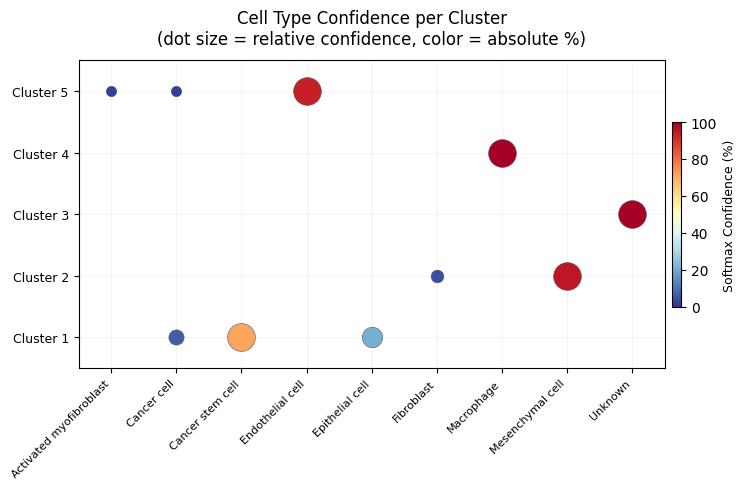

In [38]:
# Keep only cell types that have at least one confident assignment
cols_to_keep = identity_df.columns[(identity_df > 1).any(axis=0)]
identity_df_filtered = identity_df[cols_to_keep]
identity_df_norm = identity_df_filtered.div(identity_df_filtered.max(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(max(8, len(cols_to_keep) * 0.6), 5))

scatter = None
for i, cluster in enumerate(identity_df_norm.index):
    for j, ct in enumerate(identity_df_norm.columns):
        val_norm = identity_df_norm.loc[cluster, ct]
        val_raw  = identity_df_filtered.loc[cluster, ct]

        if val_raw < 1:
            continue

        # Compress size range: sqrt smooths out extreme differences
        size = (np.sqrt(val_norm) / np.sqrt(100)) * 400  # all dots between 0–400

        scatter = ax.scatter(
            j, i,
            s=size,
            c=[val_raw],
            cmap="RdYlBu_r",
            vmin=0, vmax=100,
            linewidths=0.4,
            edgecolors="#555555",
            zorder=3
        )

if scatter:
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.01)
    cbar.set_label("Softmax Confidence (%)", fontsize=9)

ax.set_xticks(range(len(identity_df_filtered.columns)))
ax.set_xticklabels(identity_df_filtered.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(identity_df_filtered.index)))
ax.set_yticklabels([f"Cluster {c}" for c in identity_df_filtered.index], fontsize=9)
ax.set_title("Cell Type Confidence per Cluster\n(dot size = relative confidence, color = absolute %)",
             fontsize=12, pad=12)
ax.set_xlim(-0.5, len(identity_df_filtered.columns) - 0.5)
ax.set_ylim(-0.5, len(identity_df_filtered.index) - 0.5)
ax.grid(True, color="#EEEEEE", linewidth=0.5, zorder=0)
ax.set_facecolor("white")

plt.tight_layout()
plt.savefig("cluster_celltype_dotplot.png", dpi=180, bbox_inches="tight")
plt.show()

In [34]:
# ── 6. SUMMARY DATAFRAME ─────────────────────────────────────────────────────

records = []
for cluster, ranking in cluster_identity_v2.items():
    best_ct, best_pct = ranking[0]
    records.append({
        "cluster"         : cluster,
        "best_cell_type"  : best_ct,
        "confidence_pct"  : round(best_pct, 2),
        "top3_ranking"    : " | ".join(f"{ct} ({p:.1f}%)" for ct, p in ranking[:3]),
    })

summary_df = pd.DataFrame(records).set_index("cluster")
print("\n\n══ SUMMARY ══════════════════════════════════════")
print(summary_df.to_string())



══ SUMMARY ══════════════════════════════════════
           best_cell_type  confidence_pct                                                                           top3_ranking
cluster                                                                                                                         
1        Cancer stem cell           71.48                Cancer stem cell (71.5%) | Epithelial cell (20.9%) | Cancer cell (6.4%)
2        Mesenchymal cell           94.98                     Mesenchymal cell (95.0%) | Fibroblast (4.2%) | Stromal cell (0.3%)
3                 Unknown          100.00                                                                       Unknown (100.0%)
4              Macrophage           99.99  Macrophage (100.0%) | Myeloid derived suppressor cell (MDSC) (0.0%) | Monocyte (0.0%)
5        Endothelial cell           93.11         Endothelial cell (93.1%) | Cancer cell (1.8%) | Activated myofibroblast (1.8%)


C1 : Cancer cell
C2 : Mesenchymal
C3 : Unkown
C4 : Macrophage
C5 : Endothelial

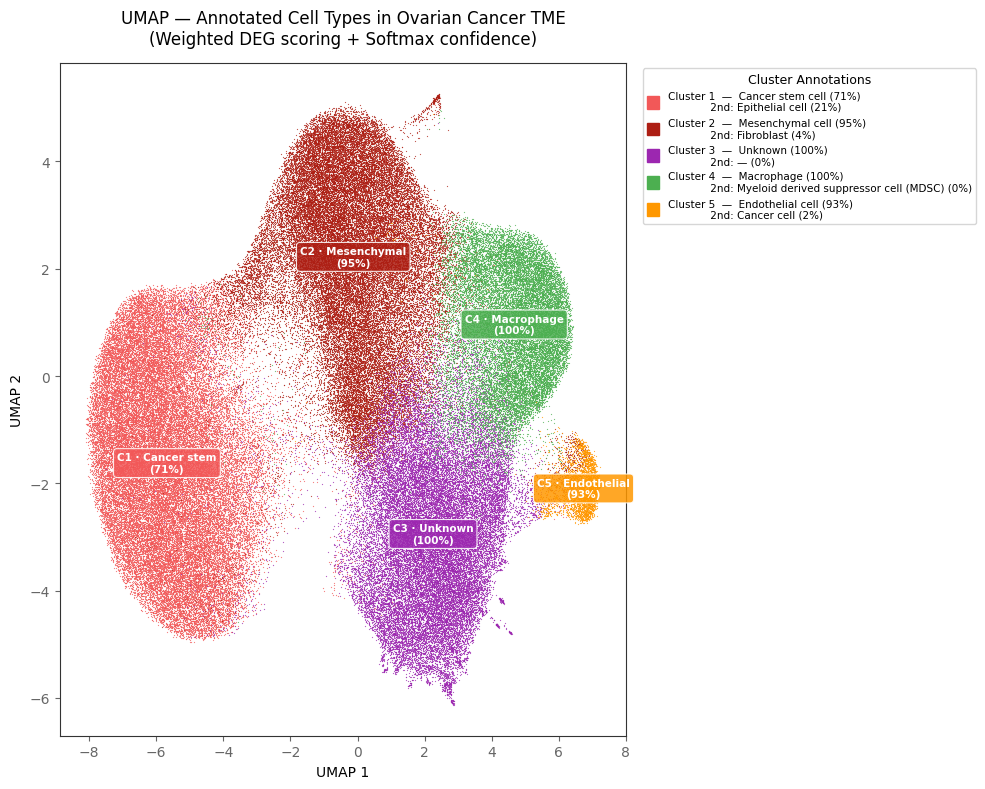

In [35]:
import matplotlib.patches as mpatches

# PLOT 1 — UMAP

cluster_labels = {}
for cluster, ranking in cluster_identity_v2.items():
    best_ct, best_pct = ranking[0]
    short = best_ct.replace(" cell", "").replace(" Cell", "")
    cluster_labels[cluster] = f"C{cluster} · {short}\n({best_pct:.0f}%)"

custom_palette = {
    cluster_ids[0]: "#F25858",
    cluster_ids[1]: "#AD1E13",
    cluster_ids[2]: "#9C27B0",
    cluster_ids[3]: "#4CAF50",
    cluster_ids[4]: "#FF9800",
}

centroids = (
    umap_df.groupby("Cluster")[["UMAP-1", "UMAP-2"]]
    .median()
    .to_dict("index")
)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

for cluster in sorted(umap_df["Cluster"].unique()):
    sub = umap_df[umap_df["Cluster"] == cluster]
    ax.scatter(
        sub["UMAP-1"], sub["UMAP-2"],
        c=custom_palette[cluster],
        s=0.8,
        linewidths=0,
        alpha=0.75,
        rasterized=True,
        label=cluster,
    )

for cluster, centroid in centroids.items():
    label_text = cluster_labels.get(cluster, f"C{cluster}")
    x, y = centroid["UMAP-1"], centroid["UMAP-2"]
    ax.text(
        x, y, label_text,
        fontsize=7.5,
        color="white",
        fontweight="bold",
        ha="center", va="center",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor=custom_palette[cluster],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.85,
        ),
        zorder=10,
    )

legend_handles = []
for cluster in sorted(custom_palette.keys()):
    best_ct, best_pct = cluster_identity_v2[cluster][0]
    top2_ct, top2_pct = cluster_identity_v2[cluster][1] if len(cluster_identity_v2[cluster]) > 1 else ("—", 0)
    legend_label = (
        f"Cluster {cluster}  —  {best_ct} ({best_pct:.0f}%)\n"
        f"             2nd: {top2_ct} ({top2_pct:.0f}%)"
    )
    legend_handles.append(mpatches.Patch(color=custom_palette[cluster], label=legend_label))

leg = ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#CCCCCC",
    labelcolor="black",
    fontsize=7.5,
    title="Cluster Annotations",
    title_fontsize=9,
    handlelength=1.2,
    handleheight=1.5,
)
leg.get_title().set_color("black")

ax.set_xlabel("UMAP 1", fontsize=10)
ax.set_ylabel("UMAP 2", fontsize=10)
ax.set_title(
    "UMAP — Annotated Cell Types in Ovarian Cancer TME\n"
    "(Weighted DEG scoring + Softmax confidence)",
    fontsize=12, pad=14,
)
ax.tick_params(colors="#666666")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

plt.tight_layout()
plt.savefig("umap_annotated.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

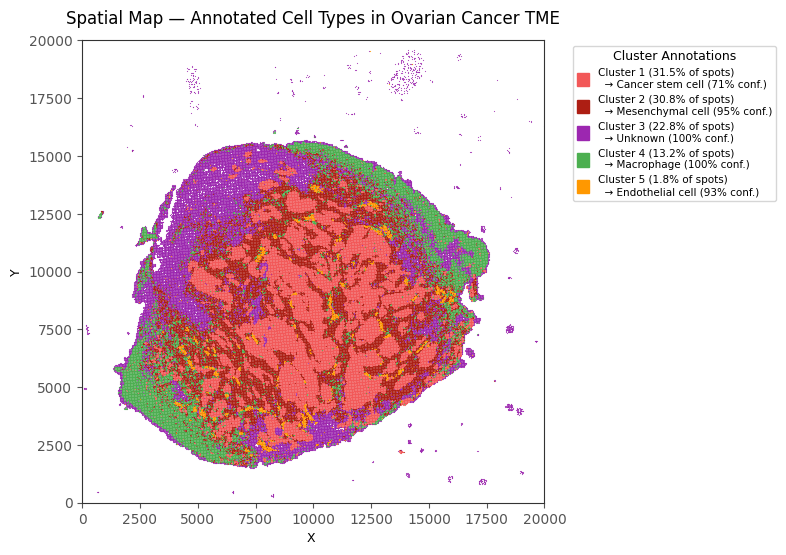

In [36]:
# PLOT 2 — SPATIAL MAP

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

for cluster in sorted(plot_df["Cluster"].unique()):
    sub = plot_df[plot_df["Cluster"] == cluster]
    ax.scatter(
        sub["pxl_col_in_fullres"],
        sub["pxl_row_in_fullres"],
        c=custom_palette[cluster],
        s=0.7,
        linewidths=0,
        alpha=0.85,
        rasterized=True,
    )

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xlim(0, 20000)
ax.set_ylim(0, 20000)

legend_handles = []
for cluster in sorted(cluster_percentages.index):
    best_ct, best_pct = cluster_identity_v2[cluster][0]
    label = (
        f"Cluster {cluster} ({cluster_percentages[cluster]:.1f}% of spots)\n"
        f"  → {best_ct} ({best_pct:.0f}% conf.)"
    )
    legend_handles.append(mpatches.Patch(color=custom_palette[cluster], label=label))

leg = ax.legend(
    handles=legend_handles,
    title="Cluster Annotations",
    title_fontsize=9,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#CCCCCC",
    labelcolor="black",
    fontsize=7.5,
    handlelength=1.2,
    handleheight=1.6,
)
leg.get_title().set_color("black")

ax.set_title(
    "Spatial Map — Annotated Cell Types in Ovarian Cancer TME",
    fontsize=12, pad=12,
)
ax.set_xlabel("X ", fontsize=9)
ax.set_ylabel("Y", fontsize=9)
ax.tick_params(colors="#555")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

plt.tight_layout()
plt.savefig("spatial_annotated.png", dpi=180,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()